In [14]:
import pandas as pd
import numpy as np

In [15]:
from pandas.core import indexing
df = pd.read_csv('/content/gallbladder_cancer_dataset.csv')
# df.drop(columns=['Patient_ID'], inplace=True)
df = df.select_dtypes(exclude=['int64','float64']) # Faqat object ko'rinishidagilarni olib qolganlarini exclude qilamiz
df.head(5)

,Patient_ID,Gender,Ethnicity,Smoking_History,Alcohol_Consumption,Family_History,Diabetes,Gallstones,Abdominal_Pain,Jaundice,Lymph_Node_Involvement,Stage,Treatment_Type,Outcome
0,PID_1,Female,Hispanic,Yes,No,Yes,Yes,No,Yes,Yes,No,II,Chemotherapy,Deceased
1,PID_2,Female,Asian,No,No,No,Yes,No,No,Yes,No,II,Chemotherapy,Deceased
2,PID_3,Male,African,Yes,Yes,Yes,No,No,No,No,No,III,Chemotherapy,Deceased
3,PID_4,Female,Caucasian,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,III,Chemotherapy,Deceased
4,PID_5,Male,Caucasian,No,Yes,No,Yes,No,Yes,No,No,IV,Chemotherapy,Deceased


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Patient_ID              1000 non-null   object
 1   Gender                  1000 non-null   object
 2   Ethnicity               1000 non-null   object
 3   Smoking_History         1000 non-null   object
 4   Alcohol_Consumption     1000 non-null   object
 5   Family_History          1000 non-null   object
 6   Diabetes                1000 non-null   object
 7   Gallstones              1000 non-null   object
 8   Abdominal_Pain          1000 non-null   object
 9   Jaundice                1000 non-null   object
 10  Lymph_Node_Involvement  1000 non-null   object
 11  Stage                   1000 non-null   object
 12  Treatment_Type          1000 non-null   object
 13  Outcome                 1000 non-null   object
dtypes: object(14)
memory usage: 109.5+ KB


In [17]:
from sklearn.preprocessing import LabelEncoder

# Label encoder orqali object dtypeslarni int ko'rinishiga o'tkazib olamiz

for col in df.columns:
  df[col] = LabelEncoder().fit_transform(df[col])

df.head()

,Patient_ID,Gender,Ethnicity,Smoking_History,Alcohol_Consumption,Family_History,Diabetes,Gallstones,Abdominal_Pain,Jaundice,Lymph_Node_Involvement,Stage,Treatment_Type,Outcome
0,0,0,3,1,0,1,1,0,1,1,0,1,0,1
1,112,0,1,0,0,0,1,0,0,1,0,1,0,1
2,223,1,0,1,1,1,0,0,0,0,0,2,0,1
3,334,0,2,1,1,1,1,1,0,1,1,2,0,1
4,445,1,2,0,1,0,1,0,1,0,0,3,0,1


Stage                    -0.046651
Smoking_History          -0.040781
Treatment_Type           -0.037126
Gender                   -0.018508
Abdominal_Pain           -0.010910
Diabetes                  0.002768
Ethnicity                 0.005731
Patient_ID                0.012510
Jaundice                  0.020528
Alcohol_Consumption       0.029230
Family_History            0.046253
Lymph_Node_Involvement    0.073041
Gallstones                0.089968
Outcome                   1.000000
dtype: float64


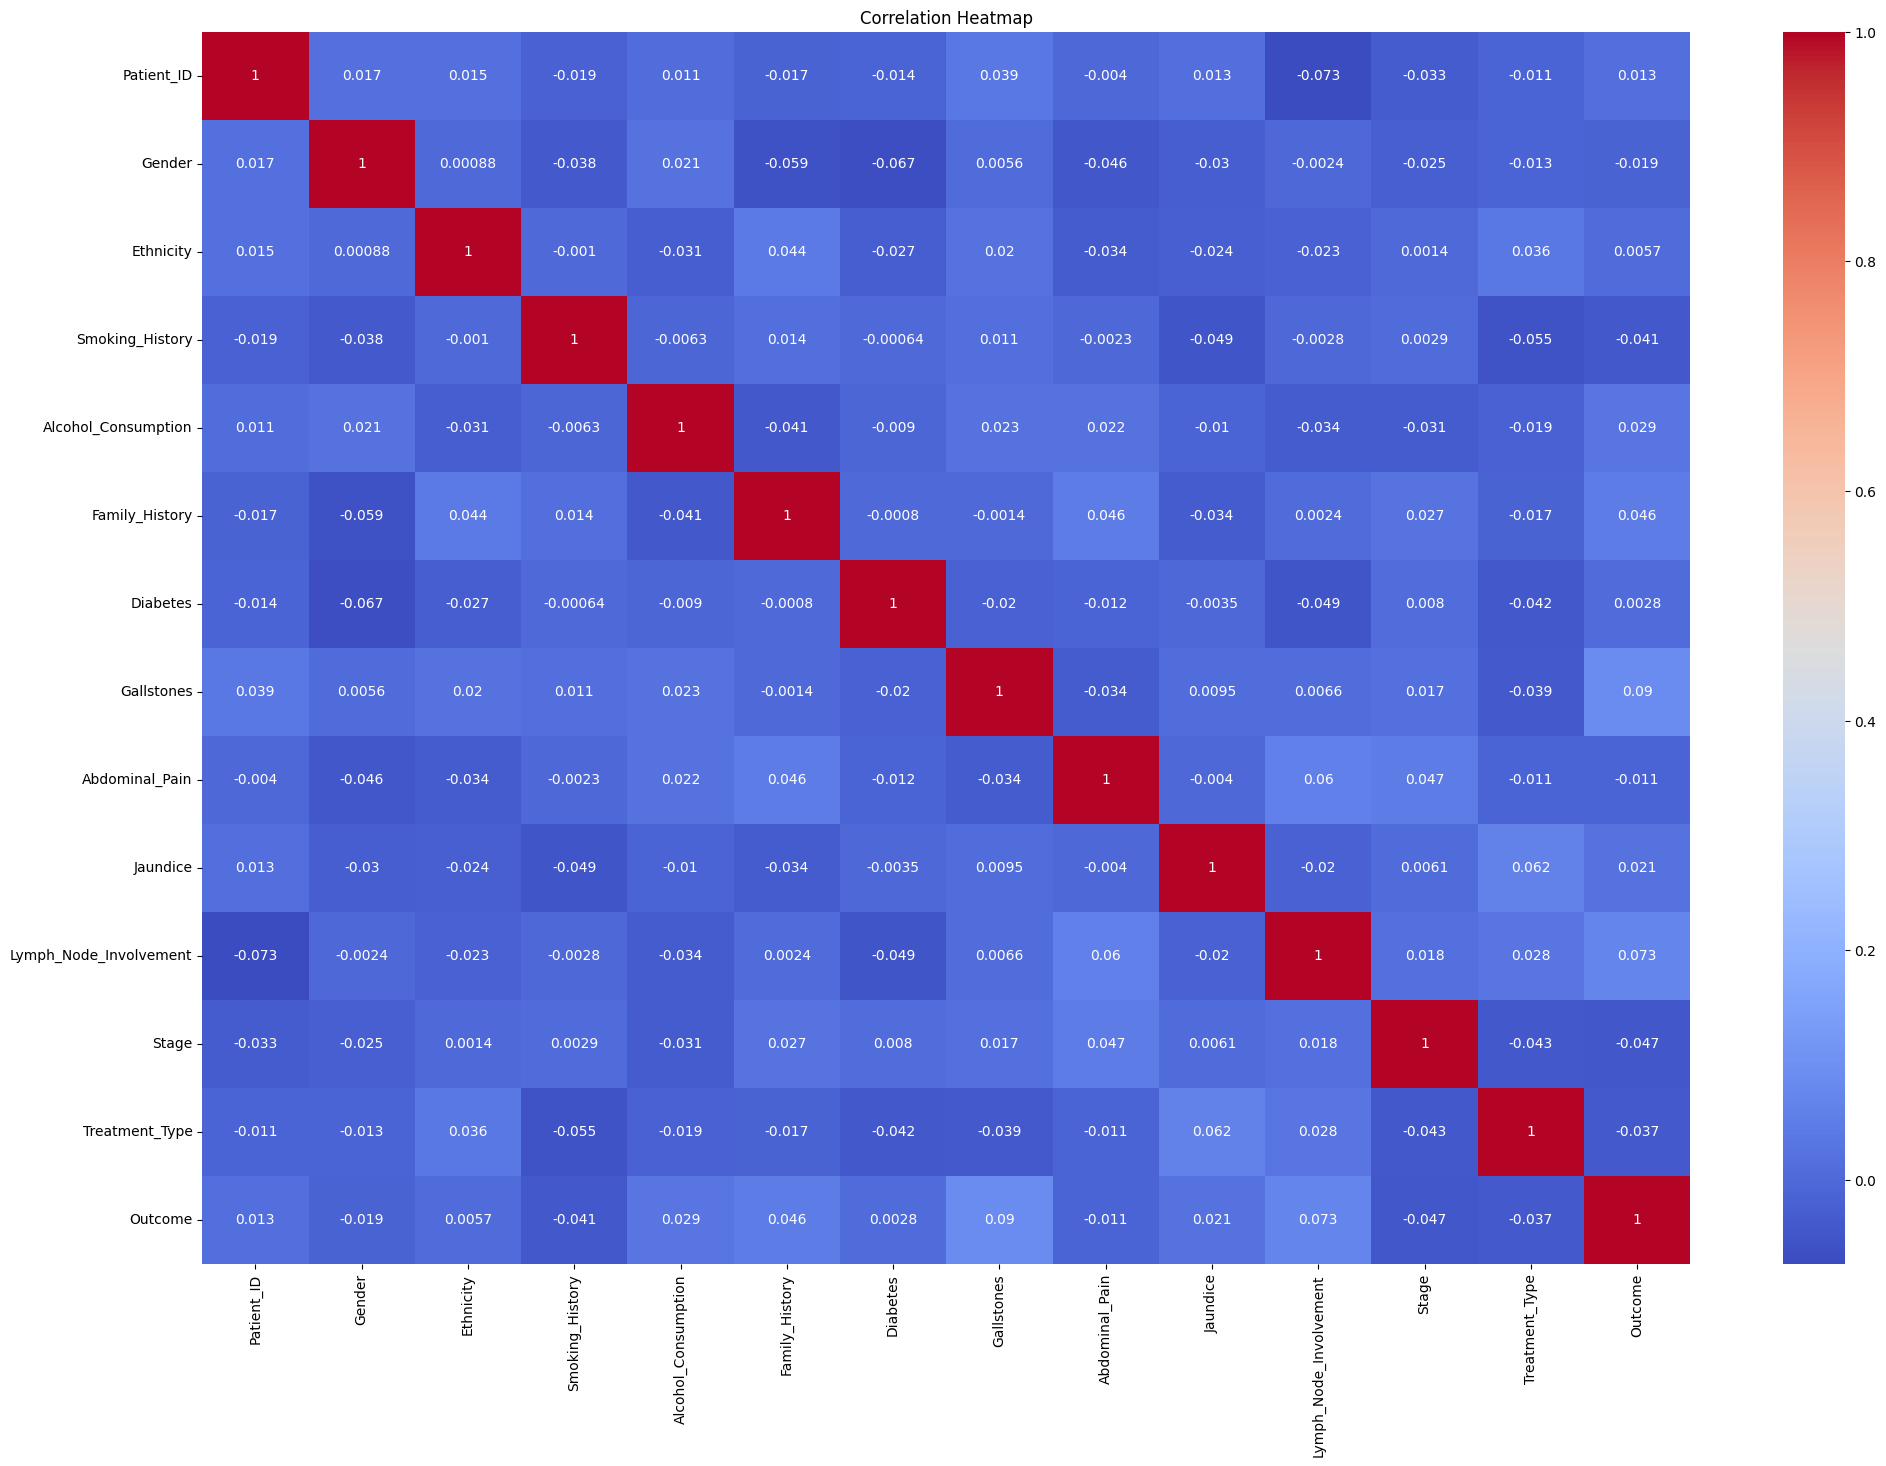

In [18]:
# Let's see if there is any correlation
import matplotlib.pyplot as plt
import seaborn as sns


df_correlated = df.corrwith(df['Outcome'], axis=0)
print(df_correlated.sort_values())

df_correlated.copy()
df_correlated = df.select_dtypes(include='number')
plt.figure(figsize=(24, 16))
sns.heatmap(df_correlated.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Naive Bayes (Logistic regression) uchun scratchdan cod yozish**

In [19]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

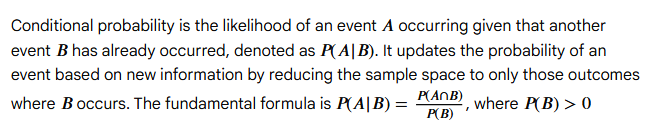

In [20]:
# Let's write a function to calculate conditional probability for each Patient ID

def calculate_patient_con_probab(X, y):
  total_patient = len(df)
  P_X = df[X].sum() # Probability for all columns

  # Joint probability for X and y
  joint_prob = ((df[X] == 1) & (df[y] == 1)).sum()

  # For each patient calculate the conditional probability P (y|X)
  prob_column = []
  for _, row in df.iterrows():
    if row[X] == 1:
      prob = joint_prob / P_X
    else:
      prob = 0
    prob_column.append(prob)

  return prob_column

# List of columns for the patient's information
patient_history = ['Gender', 'Smoking_History', 'Alcohol_Consumption', 'Family_History', 'Diabetes', 'Gallstones',
                     'Abdominal_Pain', 'Jaundice', 'Lymph_Node_Involvement', 'Treatment_Type']

# Calculate conditional probability for each user and each patient_history
for history in patient_history:
  df[f'P(Outcome | {history})'] = calculate_patient_con_probab(history, 'Outcome')

# Displayin the dataset with the calculated conditional probabilities for each patient
print(df[[f'P(Outcome | {history})' for history in patient_history]].head())

# Save the data in exel format
df.to_excel('Patient_con_probab_gallbladder.xlsx', index=False)

   P(Outcome | Gender)  P(Outcome | Smoking_History)  \
0             0.000000                      0.572233   
1             0.000000                      0.000000   
2             0.582205                      0.572233   
3             0.000000                      0.572233   
4             0.582205                      0.000000   

   P(Outcome | Alcohol_Consumption)  P(Outcome | Family_History)  \
0                          0.000000                     0.614433   
1                          0.000000                     0.000000   
2                          0.605749                     0.614433   
3                          0.605749                     0.614433   
4                          0.605749                     0.000000   

   P(Outcome | Diabetes)  P(Outcome | Gallstones)  \
0               0.592308                 0.000000   
1               0.592308                 0.000000   
2               0.000000                 0.000000   
3               0.592308                 0

**Naive Bayes (Logistic regression) uchun sklerandan chaqirib kod yozish**

In [21]:
from sklearn.linear_model import LogisticRegression

In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(df[patient_history], df['Outcome'])

df['Predicted_Prob'] = model.predict_proba(df[patient_history])[:,1]

print(df['Predicted_Prob'])



0      0.542817
1      0.555787
2      0.543938
3      0.737601
4      0.528480
         ...   
995    0.670400
996    0.604841
997    0.607213
998    0.547970
999    0.646617
Name: Predicted_Prob, Length: 1000, dtype: float64


In [23]:
# mse and rmse calculation
y_test = df['Outcome']
y_predict = df['Predicted_Prob']

def mse(y_test, y_predict):
  return np.mean(y_test - y_predict)**2

mse = mse(y_test, y_predict)
rmse = np.sqrt(mse)
print(f'mse: {mse}\n')
print(f'rmse: {rmse}')

mse: 5.276788844957901e-10

rmse: 2.2971262144161563e-05


In [24]:
# y_test andy_predict into one DataFrame
resultDF = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_predict
    })
print(resultDF)
resultDF.to_excel('ResultsDF.xlsx', index=False)

     Actual  Predicted
0         1   0.542817
1         1   0.555787
2         1   0.543938
3         1   0.737601
4         1   0.528480
..      ...        ...
995       0   0.670400
996       0   0.604841
997       1   0.607213
998       1   0.547970
999       1   0.646617

[1000 rows x 2 columns]
